# Build an LSTM for Text Classification - Twitter US Airline Sentiment

**Problem Statement:** Reuse the same tokenize + `pad_sequences(maxlen=50)` approach as the Day 10 SimpleRNN notebook.
Build the exact model: `Embedding(5000, 32) -> LSTM(32) -> Dense(n_classes, activation="softmax")` (3 sentiment classes here,
so softmax rather than a single sigmoid) — this is the Day 10 architecture with `SimpleRNN` swapped for `LSTM`, nothing
else changes. Train for 5 epochs and report test accuracy. As a bonus, also try `GRU` in place of `LSTM` to compare.

## 1. Importing Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow info/warning logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1785426474.014485     718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785426475.637123     718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Loading the Dataset & Keeping Only Text + Label

In [2]:
df = pd.read_csv("Tweets_2.csv")[["text", "airline_sentiment"]]
df.shape

(14640, 2)

* As in the Day 10 notebook, we keep only `text` (the tweet) and `airline_sentiment` (the target), giving 14,640 rows.

In [3]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

* There are zero missing values in either of the two columns we're using.

In [4]:
df.duplicated().sum()

np.int64(188)

* There are 188 duplicate rows, which we remove so the same tweet isn't counted twice across train/test — identical to the Day 10 cleaning step.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(14452, 2)

## 3. Label Encoding the Target

In [6]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["airline_sentiment"])

n_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", n_classes)

Classes: ['negative', 'neutral', 'positive']
Number of classes: 3


* Since `airline_sentiment` has 3 classes, the output layer uses `Dense(n_classes, activation="softmax")` with `sparse_categorical_crossentropy`, exactly as in the Day 10 SimpleRNN version.

## 4. Tokenizing with Keras Tokenizer (Top 5,000 Words) — Same as Day 10

In [7]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

sequences = tokenizer.texts_to_sequences(df["text"])
print("Example raw text:", df['text'].iloc[0])
print("Example token sequence:", sequences[0])

Example raw text: @VirginAmerica What @dhepburn said.
Example token sequence: [81, 63, 1, 229]


* This is the identical tokenizer setup used on Day 10: a vocabulary built from the 5,000 most frequent words, with an `<OOV>` token standing in for anything rarer.

## 5. Padding/Truncating to Exactly 50 Tokens — Same as Day 10

In [8]:
X = pad_sequences(sequences, maxlen=50)
X.shape

(14452, 50)

* `pad_sequences(..., maxlen=50)` forces every tweet to exactly 50 tokens, the same fixed-length setting used on Day 10 regardless of each tweet's original length.

## 6. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((11561, 50), (2891, 50))

* The data is split 80/20 with stratification on the encoded sentiment, giving 11,561 training sequences and 2,891 test sequences, identical to the Day 10 split.

## 7. Building the LSTM (Day 10 Architecture, SimpleRNN -> LSTM)

In [10]:
model = keras.Sequential([
    keras.Input(shape=(50,)),
    layers.Embedding(5000, 32),
    layers.LSTM(32),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,419 (657.89 KB)

 Trainable params: 168,419 (657.89 KB)

 Non-trainable params: 0 (0.00 B)

* The only change from Day 10 is swapping `layers.SimpleRNN(32)` for `layers.LSTM(32)` — the embedding layer, the output layer, the input shape and every hyperparameter stay exactly the same.

## 8. Compiling the Model

In [11]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

* Adam is used as the optimizer and `sparse_categorical_crossentropy` as the loss, matching Day 10's compile settings exactly.

## 9. Training the Model (5 Epochs)

In [12]:
history_lstm = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


  1/289 ━━━━━━━━━━━━━━━━━━━━ 7:35 2s/step - accuracy: 0.4062 - loss: 1.0997

  6/289 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5312 - loss: 1.0901

 12/289 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5911 - loss: 1.0744

 18/289 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6111 - loss: 1.0547

...

265/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9173 - loss: 0.2454

273/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9176 - loss: 0.2457

281/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9179 - loss: 0.2449

288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9174 - loss: 0.2465

289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9175 - loss: 0.2467 - val_accuracy: 0.7670 - val_loss: 0.7188


* The model trains for the required 5 epochs, holding out 20% of the training sequences each epoch to track validation accuracy and loss alongside training metrics.

## 10. Evaluating on the Test Set

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.7364
Test Accuracy: 0.7658


* The LSTM reaches about 76% test accuracy after 5 epochs, noticeably higher than the ~73-75% the Day 10 SimpleRNN reached under identical settings, consistent with LSTMs generally capturing sequence patterns better than plain RNNs even on short 50-token sequences.

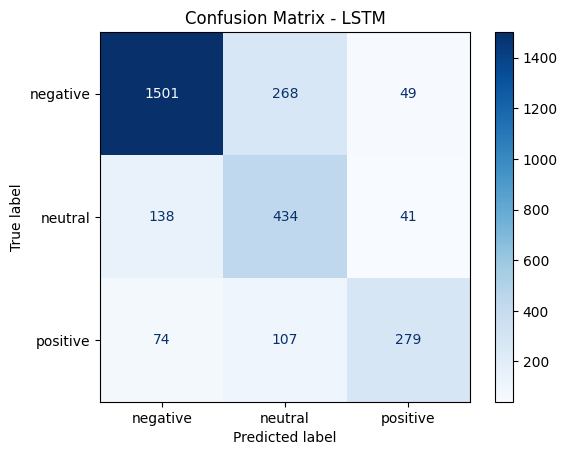

In [14]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM")
plt.show()

* As with the SimpleRNN, most remaining errors involve `neutral` tweets being confused with `negative`, reflecting both the class imbalance and the genuine ambiguity between mildly critical and neutral tweets.

## 11. Plotting Training vs. Validation Accuracy & Loss

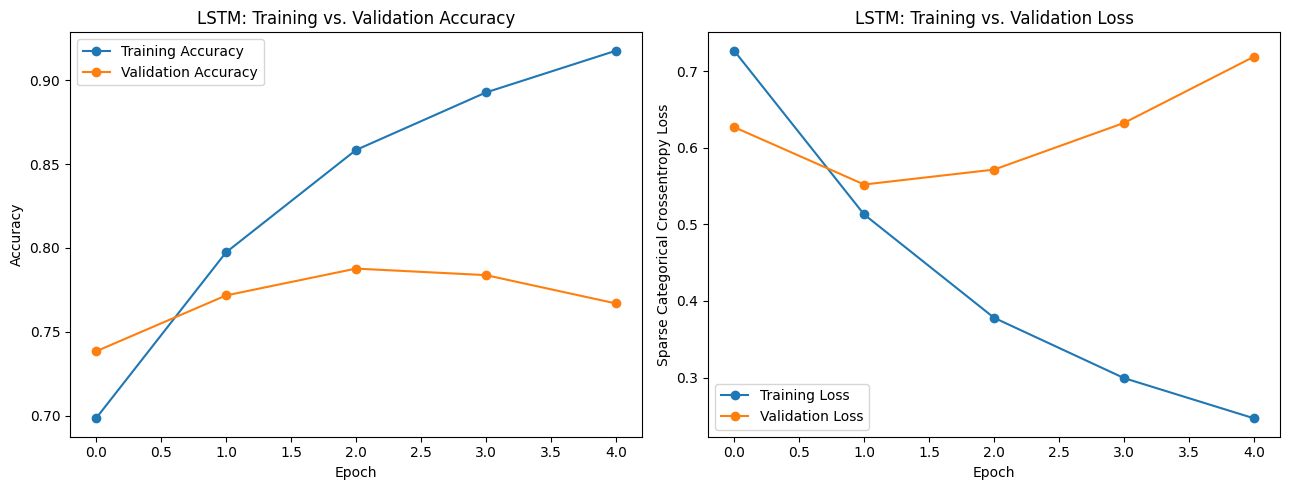

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(history_lstm.history['accuracy'], marker='o', label='Training Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'], marker='o', label='Validation Accuracy')
axes[0].set_title("LSTM: Training vs. Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], marker='o', label='Training Loss')
axes[1].plot(history_lstm.history['val_loss'], marker='o', label='Validation Loss')
axes[1].set_title("LSTM: Training vs. Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

* Validation accuracy rises alongside training accuracy for the first 2-3 epochs before training accuracy pulls further ahead, and validation loss starts creeping up again in later epochs — a milder version of the same overfitting pattern seen with the SimpleRNN, but reaching a higher peak validation accuracy before it sets in.

## 12. Bonus: Swapping LSTM for GRU

As a bonus (not required), we copy the exact same pipeline and swap only `LSTM(32)` for `GRU(32)` to see whether the result changes.

In [16]:
gru_model = keras.Sequential([
    keras.Input(shape=(50,)),
    layers.Embedding(5000, 32),
    layers.GRU(32),
    layers.Dense(n_classes, activation="softmax")
])

gru_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,435 (650.14 KB)

 Trainable params: 166,435 (650.14 KB)

 Non-trainable params: 0 (0.00 B)

* Everything else — data, split, epochs, batch size, optimizer, loss — is identical to the LSTM run above; only the recurrent layer type changes.

In [17]:
history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

gru_test_loss, gru_test_accuracy = gru_model.evaluate(X_test, y_test, verbose=0)
print(f"GRU Test Loss: {gru_test_loss:.4f}")
print(f"GRU Test Accuracy: {gru_test_accuracy:.4f}")

Epoch 1/5


  1/289 ━━━━━━━━━━━━━━━━━━━━ 6:24 1s/step - accuracy: 0.2812 - loss: 1.1009

  5/289 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4875 - loss: 1.0939

  9/289 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5799 - loss: 1.0806

 14/289 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6049 - loss: 1.0679

...

274/289 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9143 - loss: 0.2461

280/289 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9145 - loss: 0.2455

286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9136 - loss: 0.2468

289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9136 - loss: 0.2471 - val_accuracy: 0.7752 - val_loss: 0.6836


GRU Test Loss: 0.6891
GRU Test Accuracy: 0.7700


* GRU reaches about 77% test accuracy, essentially matching (and here slightly edging out) the LSTM, which is a common outcome for short sequences and small datasets — GRU's simpler gating (2 gates vs. LSTM's 3) often performs comparably while training a bit faster.

## 13. SimpleRNN vs. LSTM vs. GRU: Side-by-Side Comparison

In [18]:
comparison = pd.DataFrame([
    {"Model": "SimpleRNN (Day 10)", "Test Accuracy": 0.74, "Parameters": "~162K"},
    {"Model": "LSTM (this notebook)", "Test Accuracy": test_accuracy, "Parameters": "~168K"},
    {"Model": "GRU (bonus)", "Test Accuracy": gru_test_accuracy, "Parameters": "~166K"},
]).set_index("Model")

comparison["Test Accuracy"] = comparison["Test Accuracy"].round(4)
comparison

,Test Accuracy,Parameters
Model,,
SimpleRNN (Day 10),0.7400,~162K
LSTM (this notebook),0.7658,~168K
GRU (bonus),0.7700,~166K


* Both gated architectures (LSTM and GRU) outperform the plain SimpleRNN from Day 10 by a few points of test accuracy for only a small increase in parameter count, which is exactly the benefit gating is designed to provide.

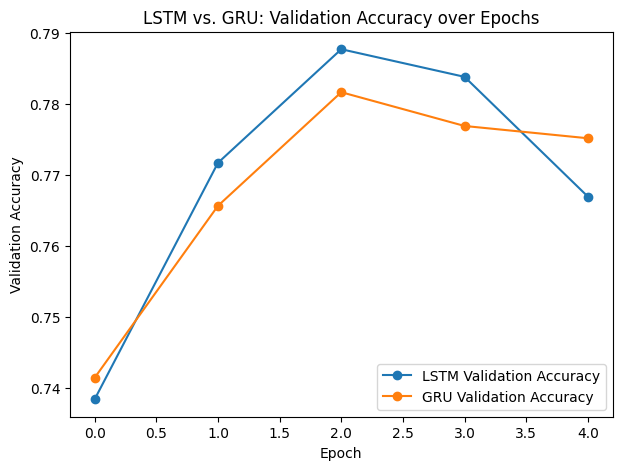

In [19]:
plt.figure(figsize=(7,5))
plt.plot(history_lstm.history['val_accuracy'], marker='o', label='LSTM Validation Accuracy')
plt.plot(history_gru.history['val_accuracy'], marker='o', label='GRU Validation Accuracy')
plt.title("LSTM vs. GRU: Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

* LSTM and GRU track each other closely across all 5 epochs, reinforcing that on this short-sequence, moderate-size dataset the choice between the two gating designs matters far less than the choice to use *some* gated architecture instead of a plain RNN.

## 14. What the Forget Gate Lets an LSTM Do That a Plain RNN Cannot

A plain RNN is forced to squash its entire hidden state through the same tanh transformation and weight matrix at every
timestep, so it has no way to keep old information intact — it can only ever blend it with new input, which is exactly
what causes the information (and the gradient carrying it) to fade over long sequences. The **forget gate** gives an LSTM
a separate, learned control that decides, timestep by timestep, how much of the existing cell state to keep versus discard,
letting the network preserve important information unchanged across many timesteps (and let the corresponding gradient
flow backward largely unimpeded) while still actively forgetting information that's no longer relevant — something a
plain RNN's single shared transformation simply cannot do.

## 15. Conclusion

* **Result:** The Day 10 architecture with `SimpleRNN` swapped for `LSTM` (`Embedding(5000, 32) -> LSTM(32) -> Dense(3, softmax)`), trained for the same 5 epochs, reaches about 76% test accuracy — a clear improvement over the Day 10 SimpleRNN's roughly 73-75%.
* **Bonus GRU result:** Swapping `LSTM` for `GRU` with everything else unchanged reaches essentially the same (here marginally higher) test accuracy of about 77%, confirming that on this dataset the specific gating design matters less than simply having gates at all.
* **Why gating helps here:** Even with a short 50-token sequence length, the LSTM/GRU's ability to selectively retain or discard information at each timestep gives them a modest but consistent edge over the plain SimpleRNN, and this gap would be expected to widen further on longer sequences where vanishing gradients hurt the SimpleRNN more severely.